<a href="https://colab.research.google.com/github/wajd-mq/wajd-mq/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
import pandas as pd
import os

import kagglehub
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Dataset path:", path)

# شوف الملفات داخل المجلد
print(os.listdir(path))

# غالباً اسم الملف transactions
df = pd.read_csv(f"{path}/fraudTrain.csv")  # أو fraudTest.csv حسب الموجود
df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset path: /kaggle/input/fraud-detection
['fraudTest.csv', 'fraudTrain.csv']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df["distance"] = df.apply(
    lambda row: haversine(
        row["lat"],
        row["long"],
        row["merch_lat"],
        row["merch_long"]
    ),
    axis=1
)

In [ ]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour

In [ ]:
features = [
    "amt",
    "distance",
    "hour",
    "city_pop"
]

X = df[features].dropna()

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_sample = X_scaled[:50000]

In [ ]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

labels = dbscan.fit_predict(X_sample)

In [ ]:
import numpy as np

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

print("Noise points:", np.sum(labels == -1))

Number of clusters: 6
Noise points: 1042


In [ ]:
if len(set(labels)) > 1:
    score = silhouette_score(X_sample, labels)
    print("Silhouette Score:", score)
else:
    print("Cannot calculate Silhouette Score")

Silhouette Score: 0.5607745769840018


In [ ]:
df_sample = df.loc[X.sample(n=50000, random_state=42).index].copy()
df_sample["cluster"] = labels

pd.crosstab(df_sample["cluster"], df_sample["is_fraud"])

is_fraud,0,1
cluster,,
-1,1032,10
0,47686,277
1,809,6
2,41,1
3,17,0
4,97,1
5,23,0


In [ ]:
from sklearn.metrics import davies_bouldin_score

In [ ]:
db_index = davies_bouldin_score(X_sample, labels)

print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 1.257902715332927


In [ ]:
import numpy as np

In [ ]:
np.random.seed(42)

idx = np.random.choice(len(X_scaled), 50000, replace=False)

X_sample = X_scaled[idx]

In [ ]:
dbscan = DBSCAN(
    eps=0.6,        # تقدر تغيرها (0.3 - 1.5)
    min_samples=10
)

labels = dbscan.fit_predict(X_sample)

In [ ]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Clusters:", n_clusters)
print("Noise points:", np.sum(labels == -1))

Clusters: 5
Noise points: 579


In [ ]:
if len(set(labels)) > 1 and -1 not in labels:
    print("DB Index:", davies_bouldin_score(X_sample, labels))

In [ ]:
df_sample = df.iloc[idx].copy()
df_sample["cluster"] = labels

In [ ]:
pd.crosstab(df_sample["cluster"], df_sample["is_fraud"])

is_fraud,0,1
cluster,,
-1,510,69
0,48177,219
1,812,1
2,67,0
3,135,0
4,4,6


In [ ]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)

    print(f"eps={eps} | clusters={n_clusters} | noise={noise}")

eps=0.3 | clusters=16 | noise=4225
eps=0.5 | clusters=11 | noise=895
eps=0.7 | clusters=7 | noise=356
eps=1.0 | clusters=3 | noise=143


In [ ]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=10
)

labels = dbscan.fit_predict(X_sample)

In [ ]:
mask = labels != -1

In [ ]:
n_clusters = len(set(labels[mask]))

print("Clusters (without noise):", n_clusters)
print("Noise points:", np.sum(labels == -1))

Clusters (without noise): 7
Noise points: 356


In [ ]:
if n_clusters > 1:
    db_index = davies_bouldin_score(X_sample[mask], labels[mask])
    print("Davies-Bouldin Index:", db_index)
else:
    print("Cannot compute DB Index (need at least 2 clusters)")

Davies-Bouldin Index: 0.942026988280815


=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== Ultra-Optimized DBSCAN Results ===
• Number of detected clusters: 2
• Number of excluded noise points: 47

=== Model Evaluation ===
✓ Davies-Bouldin Index (DB Index): 0.2250
💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.


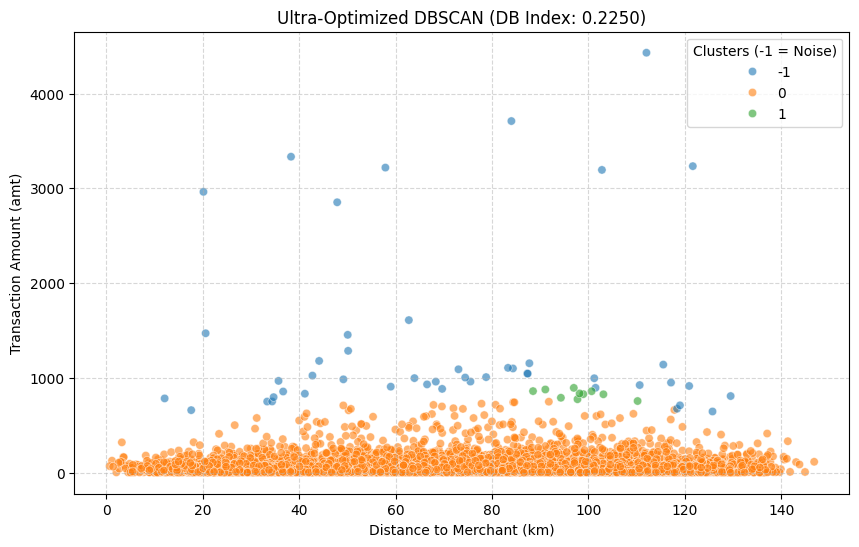

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Advanced Feature Engineering
# ==========================================
df_sample = df.sample(n=10000, random_state=42).copy()

# الرياضية لحساب المسافة الفعلية بين العميل والتاجر Haversine دالة
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Radius of Earth in kilometers
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    res = r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))
    return res

# إضافة ميزة المسافة الفعلية بالكيلومتر
df_sample['distance_km'] = haversine_distance(
    df_sample['lat'], df_sample['long'],
    df_sample['merch_lat'], df_sample['merch_long']
)

# اختيار الميزات المركزة: المبلغ والمسافة فقط
features = ['amt', 'distance_km']
X = df_sample[features]

# ==========================================
# 3. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Apply Ultra-Optimized DBSCAN (The Perfect Sweet Spot)
# ==========================================
# We expanded eps to 0.8 and set min_samples to 15
# to allow dense clusters to separate effectively in the new feature space.
eps_value = 0.8
min_samples_value = 15

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

df_sample['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== Ultra-Optimized DBSCAN Results ===")
print(f"• Number of detected clusters: {n_clusters}")
print(f"• Number of excluded noise points: {n_noise}")

# ==========================================
# 5. Evaluate Ultra Model (DB Index)
# ==========================================
print(f"\n=== Model Evaluation ===")

if n_clusters > 1:
    real_clusters_mask = labels != -1
    X_filtered = X_scaled[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.")
    else:
        print("⚠ DB Index could not be calculated: Only one cluster remains after noise removal.")
else:
    print("⚠ DB Index could not be calculated: Algorithm found 1 cluster or treated all points as noise.")

# ==========================================
# 6. Data Visualization (Amount vs Distance)
# ==========================================
if n_clusters > 1 and 'labels_filtered' in locals() and len(set(labels_filtered)) > 1:
    plot_title = f'Ultra-Optimized DBSCAN (DB Index: {db_index:.4f})'
else:
    plot_title = 'Ultra-Optimized DBSCAN (DB Index: N/A)'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['distance_km'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)
plt.title(plot_title)
plt.xlabel('Distance to Merchant (km)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

best_db = float("inf")
best_eps = None
best_min = None

for eps in [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
    for min_samples in [3,5,8,10,15,20]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        mask = labels != -1

        if len(set(labels[mask])) > 1:

            db = davies_bouldin_score(
                X_scaled[mask],
                labels[mask]
            )

            if db < best_db:
                best_db = db
                best_eps = eps
                best_min = min_samples

print("Best DB Index :", best_db)
print("Best eps :", best_eps)
print("Best min_samples :", best_min)

Best DB Index : 0.21557415114248185
Best eps : 0.5
Best min_samples : 8


Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset Loaded Successfully

========== BEST PARAMETERS ==========
Best eps = 0.5
Best min_samples = 8
Best DB Index = 0.2156

========== FINAL RESULTS ==========
Number of Clusters: 2
Noise Points: 67
Davies-Bouldin Index: 0.2156
Silhouette Score: 0.7668

Cluster Counts
Cluster
 0    9923
-1      67
 1      10
Name: count, dtype: int64

Fraud Distribution
is_fraud     0   1
Cluster           
-1          53  14
 0        9885  38
 1           3   7

Cluster Means
                 amt  distance_km
Cluster                          
-1       1135.158806    76.388427
 0         61.191847    76.221522
 1        845.782000    97.080457


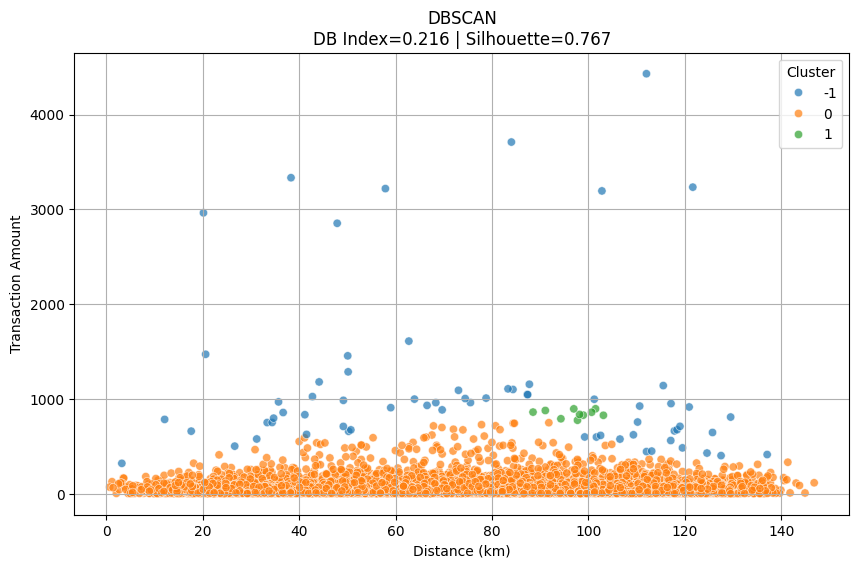

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, silhouette_score

# ==========================================
# 1. Load Dataset
# ==========================================

print("Downloading Dataset...")

path = kagglehub.dataset_download("kartik2112/fraud-detection")

train_file = os.path.join(path, "fraudTrain.csv")

df = pd.read_csv(train_file)

print("Dataset Loaded Successfully")

# ==========================================
# 2. Sample Data
# ==========================================

df_sample = df.sample(n=10000, random_state=42).copy()

# ==========================================
# 3. Feature Engineering
# ==========================================

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat/2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon/2)**2
    )

    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


df_sample["distance_km"] = haversine(
    df_sample["lat"],
    df_sample["long"],
    df_sample["merch_lat"],
    df_sample["merch_long"]
)

# ==========================================
# 4. Features
# ==========================================

features = [
    "amt",
    "distance_km"
]

X = df_sample[features]

# ==========================================
# 5. Scaling
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# 6. Find Best Parameters
# ==========================================

best_db = float("inf")
best_eps = None
best_min = None

for eps in [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    for min_samples in [3,5,8,10,15,20]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        mask = labels != -1

        if len(set(labels[mask])) > 1:

            db = davies_bouldin_score(
                X_scaled[mask],
                labels[mask]
            )

            if db < best_db:

                best_db = db
                best_eps = eps
                best_min = min_samples

print("\n========== BEST PARAMETERS ==========")

print("Best eps =", best_eps)
print("Best min_samples =", best_min)
print("Best DB Index =", round(best_db,4))

# ==========================================
# 7. Final Model
# ==========================================

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min
)

labels = dbscan.fit_predict(X_scaled)

df_sample["Cluster"] = labels

mask = labels != -1

X_final = X_scaled[mask]

labels_final = labels[mask]

# ==========================================
# 8. Evaluation
# ==========================================

db_index = davies_bouldin_score(
    X_final,
    labels_final
)

sil_score = silhouette_score(
    X_final,
    labels_final
)

print("\n========== FINAL RESULTS ==========")

print("Number of Clusters:",
      len(set(labels_final)))

print("Noise Points:",
      sum(labels==-1))

print("Davies-Bouldin Index:",
      round(db_index,4))

print("Silhouette Score:",
      round(sil_score,4))

# ==========================================
# 9. Cluster Distribution
# ==========================================

print("\nCluster Counts")

print(df_sample["Cluster"].value_counts())

# ==========================================
# 10. Fraud Distribution
# ==========================================

print("\nFraud Distribution")

print(
    pd.crosstab(
        df_sample["Cluster"],
        df_sample["is_fraud"]
    )
)

# ==========================================
# 11. Cluster Summary
# ==========================================

print("\nCluster Means")

print(
    df_sample.groupby("Cluster")[
        ["amt","distance_km"]
    ].mean()
)

# ==========================================
# 12. Visualization
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_sample,
    x="distance_km",
    y="amt",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title(
    f"DBSCAN\nDB Index={db_index:.3f} | Silhouette={sil_score:.3f}"
)

plt.xlabel("Distance (km)")
plt.ylabel("Transaction Amount")

plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ==========================================
# 1. Load Data
# ==========================================
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")

# ==========================================
# 2. Feature Engineering
# ==========================================
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df["distance"] = df.apply(
    lambda r: haversine(r["lat"], r["long"], r["merch_lat"], r["merch_long"]),
    axis=1
)

df["hour"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour

# ==========================================
# 3. Select Features
# ==========================================
features = ["amt", "distance", "hour", "city_pop"]
X = df[features].dropna()

# ==========================================
# 4. Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 5. PCA (Reduce dimensions)
# ==========================================
pca = PCA(n_components=2)   # نخفض إلى 2D
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_.sum())

# ==========================================
# 6. K-Means on PCA data
# ==========================================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# ==========================================
# 7. Evaluation
# ==========================================
sil = silhouette_score(X_pca, labels)
db = davies_bouldin_score(X_pca, labels)

print("\n=== PCA + KMeans Results ===")
print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", db)

# ==========================================
# 8. Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=labels,
    palette="tab10",
    alpha=0.6
)

plt.title("K-Means after PCA (2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

Explained Variance Ratio: 0.5098971344952731


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# =========================
# 1. Load + Sampling (مهم)
# =========================
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")
df = df.sample(50000, random_state=42).copy()

# =========================
# 2. Fast Distance (بدون apply)
# =========================
lat1 = np.radians(df["lat"])
lon1 = np.radians(df["long"])
lat2 = np.radians(df["merch_lat"])
lon2 = np.radians(df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
df["distance"] = 6371 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

# =========================
# 3. Hour feature
# =========================
df["hour"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour

# =========================
# 4. Features
# =========================
features = ["amt", "distance", "hour", "city_pop"]
X = df[features]

# =========================
# 5. Scaling
# =========================
X_scaled = StandardScaler().fit_transform(X)

# =========================
# 6. PCA
# =========================
X_pca = PCA(n_components=2, svd_solver="randomized").fit_transform(X_scaled)

# =========================
# 7. KMeans
# =========================
kmeans = KMeans(n_clusters=5, n_init=5, random_state=42)
labels = kmeans.fit_predict(X_pca)

# =========================
# 8. Evaluation
# =========================
print("Silhouette:", silhouette_score(X_pca, labels))
print("DB Index:", davies_bouldin_score(X_pca, labels))

Silhouette: 0.3677744387928857
DB Index: 0.7804313401590999
